# Agenda

Naive Bayes - how it works

Different variants of NB

Advantages, Disadvantages and Use cases

Code demo - NB and MultinomialNB

Comparision of NB with LR and SVM

# Naive Bayes - how it works

<img src="./images/naive_bayes_1.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_2.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_3.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_4.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_5.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_6.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_7.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_8.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_9.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_10.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_11.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_12.png" alt="sample" width="1000"/>

<img src="./images/naive_bayes_13.png" alt="sample" width="1000"/>

# Different variants of NB

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("./images/naive_bayes_comparison.csv")

# Show all columns without truncation
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.max_colwidth", None)  # don't truncate column values
pd.set_option("display.width", None)         # let pandas decide based on notebook width

from IPython.display import display

display(df)

,Algorithm,Description,Typical Use Cases,Key Benefits
0,Gaussian Naïve Bayes,Assumes features are continuous and follow a normal (Gaussian) distribution.,"Medical test values, sensor measurements, continuous numeric datasets.","Works well with continuous data, simple & fast, requires fewer data points."
1,Multinomial Naïve Bayes,Assumes features are counts (frequency of words/events). Uses multinomial distribution.,"Text classification (spam detection, topic modeling, sentiment analysis).","Naturally handles word counts, great for high-dimensional data, strong in NLP tasks."
2,Bernoulli Naïve Bayes,"Assumes features are binary (yes/no, 0/1). Uses Bernoulli distribution.","Document classification (presence/absence of words), sentiment classification, recommendation with binary features.","Useful when frequency doesn’t matter, handles sparse binary data, simpler representation in NLP tasks."


# Advantages and Disadvantages

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("./images/naive_bayes_pros_cons_side_by_side.csv")

# Show all columns without truncation
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.max_colwidth", None)  # don't truncate column values
pd.set_option("display.width", None)         # let pandas decide based on notebook width

from IPython.display import display

display(df)

,Advantages,Disadvantages
0,Simple and fast – easy to implement with low computational cost.,Strong independence assumption rarely holds in real-world data.
1,"Efficient with high-dimensional data (e.g., text classification).",Zero probability problem if feature not seen in training (fixed with Laplace smoothing).
2,Requires small amount of training data for parameter estimation.,Poor with continuous features unless Gaussian assumption holds.
3,Handles categorical inputs naturally.,Less flexible; complex models outperform NB on difficult tasks.
4,Performs well even if independence assumption is violated.,Requires feature engineering for best performance.
5,Robust to irrelevant features (they often cancel out).,Not suitable for regression tasks (only classification).
6,Provides probabilistic interpretation (class probabilities).,NaN


# Code demo - NB and Multinomial NB

Accuracy: 0.7802690582959642

Classification Report:
               precision    recall  f1-score   support

           0      0.814     0.832     0.823       137
           1      0.723     0.698     0.710        86

    accuracy                          0.780       223
   macro avg      0.769     0.765     0.767       223
weighted avg      0.779     0.780     0.780       223



/var/folders/yv/kny11ztx72q6t7lv7fh0rg8h0000gn/T/ipykernel_18957/81458568.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["age"].fillna(X["age"].median(), inplace=True)
/var/folders/yv/kny11ztx72q6t7lv7fh0rg8h0000gn/T/ipykernel_18957/81458568.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["age"].fillna(X["age"].median(), inplace

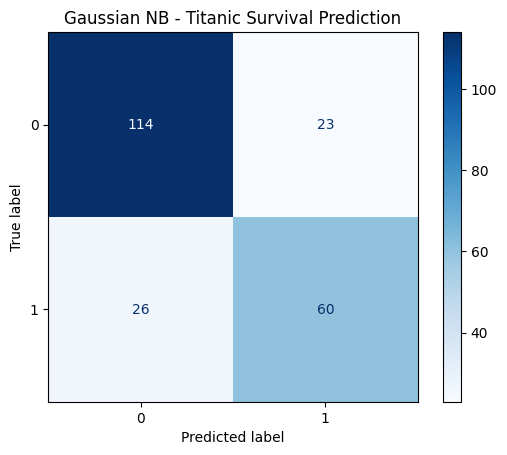

In [3]:
# pip install seaborn scikit-learn
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Load Titanic dataset from seaborn
df = sns.load_dataset("titanic").copy()

# 2) Select useful features (continuous + categorical)
features = ["pclass", "sex", "age", "fare", "sibsp", "parch", "embarked"]
target = "survived"

X = df[features]
y = df[target]

# 3) Handle missing values
X["age"].fillna(X["age"].median(), inplace=True)
X["fare"].fillna(X["fare"].median(), inplace=True)
X["embarked"].fillna(X["embarked"].mode()[0], inplace=True)

# 4) Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# 5) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 6) Scale features (important for GNB with continuous values)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7) Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

# 8) Predictions
y_pred = gnb.predict(X_test_scaled)

# 9) Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=gnb.classes_).plot(cmap="Blues")
plt.title("Gaussian NB - Titanic Survival Prediction")
plt.show()

### Inferences from the above example:

Titanic dataset has both continuous features (age, fare) and categorical ones (sex, class, embarked).

GNB assumes every feature is conditionally independent given the survival outcome.

Even though features like pclass and fare are correlated, GNB still performs reasonably well → shows the robustness of Naïve Bayes.

GNB tends to predict the majority class (died = 0) more accurately because of class imbalance (more people died than survived).

GNB outputs class probabilities → e.g., P(Survived=1 | X) vs P(Survived=0 | X).

Fast training: even with thousands of rows, training takes milliseconds.

Demonstrates that a simple probabilistic model can already capture meaningful patterns.

Gaussian assumption may not hold perfectly: fares are skewed, not truly Gaussian (normally distributed)

This opens discussion about why tree-based or ensemble methods (Random Forest, XGBoost) often outperform NB on Titanic.

[]
Accuracy: 0.9123514431239389

Classification Report:

                          precision    recall  f1-score   support

             alt.atheism      0.910     0.915     0.913       200
           comp.graphics      0.846     0.860     0.853       243
 comp.os.ms-windows.misc      0.892     0.837     0.864       246
comp.sys.ibm.pc.hardware      0.816     0.890     0.852       245
   comp.sys.mac.hardware      0.902     0.917     0.909       241
          comp.windows.x      0.922     0.911     0.916       247
            misc.forsale      0.894     0.795     0.842       244
               rec.autos      0.930     0.911     0.921       248
         rec.motorcycles      0.941     0.960     0.950       249
      rec.sport.baseball      0.952     0.960     0.956       249
        rec.sport.hockey      0.961     0.996     0.978       250
               sci.crypt      0.934     0.964     0.948       248
         sci.electronics      0.904     0.923     0.913       246
                 s

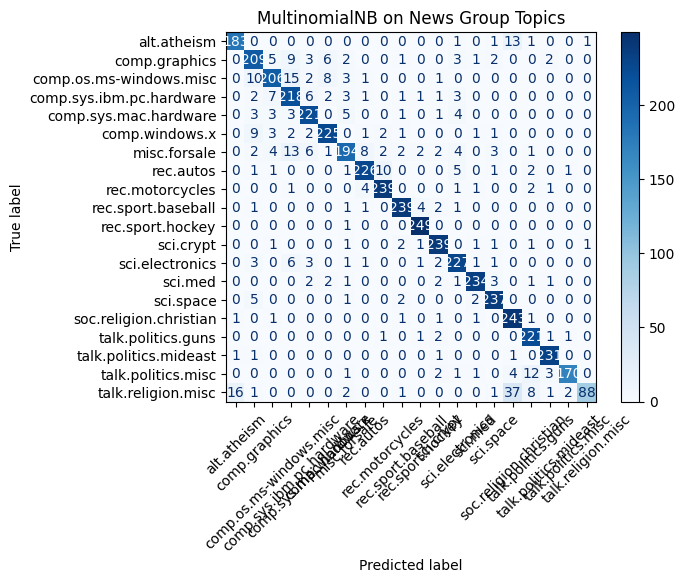

In [ ]:
# pip install scikit-learn
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Load dataset (we’ll use 4 categories to keep it small & interpretable)
# categories = ["rec.sport.baseball", "comp.graphics", "sci.space", "talk.politics.mideast"]

# newsgroups = fetch_20newsgroups(subset="all", categories=categories, shuffle=True, random_state=42)
newsgroups = fetch_20newsgroups(subset="all", shuffle=True, random_state=42)

X, y = newsgroups.data, newsgroups.target
target_names = newsgroups.target_names
print(X)

# 2) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 3) Build pipeline: CountVectorizer → TF-IDF → MultinomialNB
text_clf = Pipeline([
    ("vect", CountVectorizer(stop_words="english")),  # bag of words
    ("tfidf", TfidfTransformer()),                   # optional: TF-IDF scaling
    ("clf", MultinomialNB(alpha=0.1))                # Laplace smoothing with alpha
])

# 4) Train model
text_clf.fit(X_train, y_train)

# 5) Predictions
y_pred = text_clf.predict(X_test)

# 6) Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

# 7) Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap="Blues", xticks_rotation=45)
plt.title("MultinomialNB on News Group Topics")
plt.show()

In [9]:
# string_to_predict = "Football ground is a rectangle"
# string_to_predict = "Vaccines are costlier nowadays"

string_to_predict = "GOD is omnipresent"


In [10]:
target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [11]:
target_names[list(text_clf.predict([string_to_predict]))[0]]

'soc.religion.christian'

# Comparision of NB, MLNB, SVC and Log Reg

In [22]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("./images/algorithm_comparison.csv")

# Show all columns without truncation
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.max_colwidth", None)  # don't truncate column values
pd.set_option("display.width", None)         # let pandas decide based on notebook width

from IPython.display import display

display(df)

,Algorithm,Description,Pros,Cons,Typical Use Cases
0,Gaussian Naïve Bayes (GNB),Probabilistic classifier assuming continuous features follow a Gaussian distribution; applies Bayes’ theorem with independence assumption.,"Very fast, works with small data; Handles continuous features; Outputs probability estimates; Robust to irrelevant features",Independence assumption often violated; Gaussian assumption may not hold; Weak with correlated features,"Medical data (blood pressure, cholesterol); Sensor data classification; Quick baseline on tabular datasets"
1,Multinomial Naïve Bayes (MNB),"Probabilistic classifier assuming features are counts/frequencies (e.g., words in text).",Excellent for text classification; Handles high-dimensional sparse data; Simple & fast; Needs little data,Only works with non-negative count features; Ignores feature correlation; Ignores word order (bag-of-words),Spam detection; News/topic categorization; Sentiment analysis
2,Support Vector Regression (SVR),"Extension of SVM to regression; fits a function within an ε-insensitive margin, focusing on support vectors.",Captures non-linear patterns via kernels; Robust to outliers (ε-insensitive loss); Effective on small/medium datasets,"Sensitive to hyperparameters (C, ε, γ); Computationally heavy on large data; Harder to interpret",Stock price prediction; Energy demand forecasting; Non-linear regression tasks
3,Logistic Regression (LogReg),Linear model estimating class probabilities using a logistic (sigmoid) function.,"Simple, interpretable; Produces calibrated probabilities; Works with continuous & categorical features; Fast to train",Assumes linear boundaries; Weak on non-linear data; Sensitive to multicollinearity,"Binary classification (spam/ham, churn); Medical diagnosis; Credit risk scoring"
